# Exploratory Data Analysis(EDA)- Part 2 Using Pandas

- **Data Transformation**
- **Feature Engineering**
- **Exploration Insights**
- **Feature Selection**
- **Data Preprocessing in Insurance Industry**

In [2]:
import pandas as pd
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


## Why Data Transformation is Required

### What is Data Transformation?

It is the process of converting raw data into more suitable format or scale to improve performance and accuracy in analysis or modeling.

### Why It's Important

**Reduces Skewness:** Many real-world numerical features(like income or charges) are right skewed.

**Improve Model Performance:** Linear models assume normality and homoscedasticity; transformation helps.

**Brings All Features to Comparable Scale:** This avoids bias toward high-magnitude features.

**Handles Outliners Gently:** Some transformations compress the effect of large values.

# Common Types of Transformations

| Method          | When to Use                                              | Example Code                                      |
|----------------|----------------------------------------------------------|--------------------------------------------------|
| Log            | Right-skewed data (e.g., income, charges)                | `df['log_exp'] = np.log1p(df['expenses'])`       |
| Box-Cox        | Positive values only; used when log isn't enough         | `df['bmi_boxcox'], _ = boxcox(df['bmi'] + 1)`    |
| Z-score        | When detecting outliers using standard deviation         | `(df - df.mean()) / df.std()`                    |
| Min-Max        | When scaling is needed between 0 and 1                   | `MinMaxScaler()`                                 |
| Power Transform| Automatically selects best between log/sqrt              | `PowerTransformer() from sklearn`                |

<Axes: xlabel='charges', ylabel='Count'>

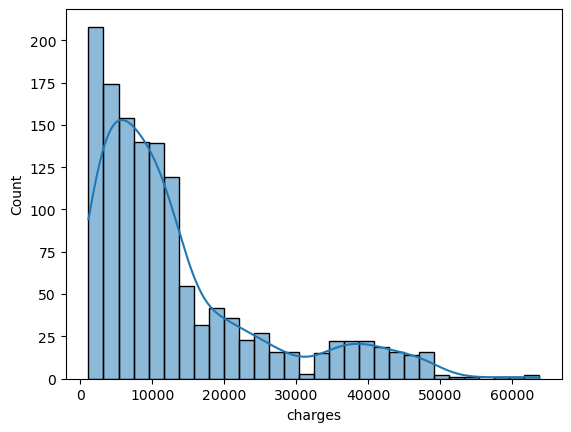

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde = True) # Before Transformation

![Skewness Distribution](skewness.jpg)

# Types of Data Distribution (Skewness)

## 1. Left-Skewed (Negative Skew)
- Tail is on the **left side**
- Most data is concentrated on the **right**
- Relationship: Mean < Median < Mode


---

## 2. Symmetric Distribution
- Data is evenly distributed on both sides
- Bell-shaped curve (normal distribution)
- Relationship: Mean = Median = Mode


---

## 3. Right-Skewed (Positive Skew)
- Tail is on the **right side**
- Most data is concentrated on the **left**
- Relationship: Mode < Median < Mean


---

## 📊 Summary Table

| Distribution Type | Shape Description        | Relationship                |
|------------------|------------------------|-----------------------------|
| Left-Skewed      | Tail on left           | Mean < Median < Mode        |
| Symmetric        | Balanced               | Mean = Median = Mode        |
| Right-Skewed     | Tail on right          | Mode < Median < Mean        |

In [6]:
# Box-Cox on Positive BMI

from scipy.stats import boxcox

df['bmi_boxcox'],_ = boxcox(df['bmi']+1)

<Axes: xlabel='log_charges', ylabel='Count'>

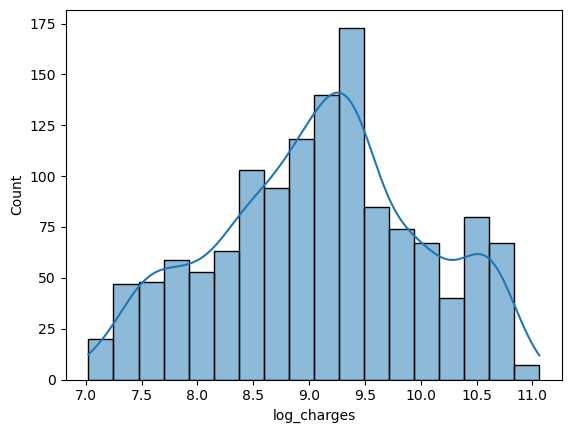

In [7]:
df['log_charges'] = np.log1p(df['charges'])

sns.histplot(df['log_charges'], kde = True) #After Transform

### Inference

The transformed distribution is more symmetric, which is better for regression and visualization.

In Statistics whenever histogram is hsowing data distribution in form of bell shape curve,

it is normal distribution otherwise skewed distribution.


In [8]:
df.shape

(1338, 9)

In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455


## Feature Engineering

### Create meaningful features

In [10]:
#before applying feature engineering
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455


In [11]:
#Creating Category as per bmi and age

In [12]:
df['bmi_cat'] = pd.cut(df['bmi'], bins = [0,18.5,25,30,100], labels = ['under','normal','over','obese'])


In [13]:
df['age_group'] = pd.cut(df['age'], bins =[17,30,45,60,100], labels = ['young','adult','mature','senior'])

In [14]:
df['age_smoker'] = df['age'] * (df['smoker']=='yes')

In [15]:
#after applying feature engineering
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult,0


## Data Distribution Analysis

Transformed distribution help us better understand data patterns and reduce skewness.

Boxplots are ideal for comparing how different group affects a continous variable.

<Axes: xlabel='log_charges', ylabel='Count'>

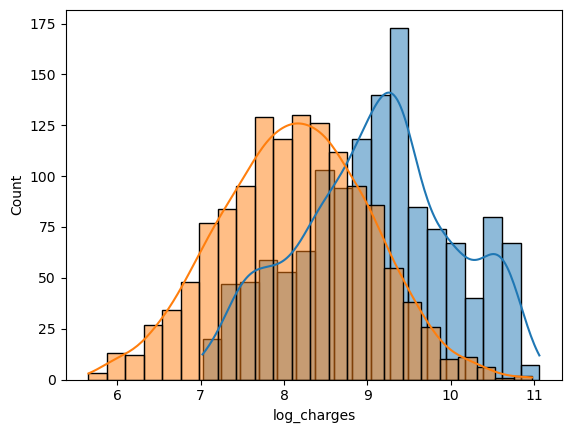

In [15]:
# Distribution plots

sns.histplot(df['log_charges'], kde = True)
sns.histplot(df['bmi_boxcox'], kde = True)


### Inference

This plot shows the distribution of expenses after applying a log transformation.

Originally, the data was right-skewed, meaning most people had low expenses but a few had very high ones.

Log transformation makes the distribution more normal and symmetric - ideal for many statistical and machine learning models.

<Axes: xlabel='bmi_cat', ylabel='charges'>

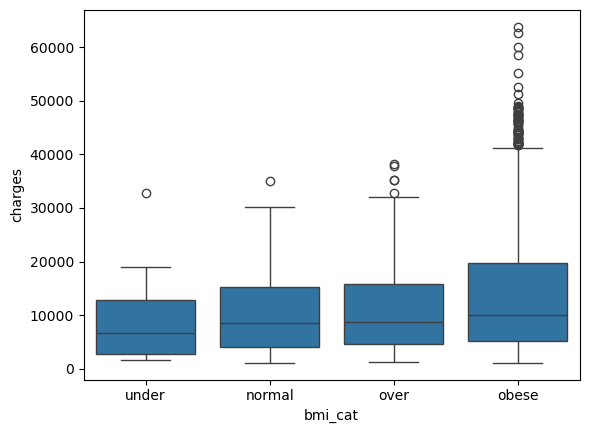

In [16]:
# Boxplot for categorical Distributions

sns.boxplot(x = 'bmi_cat', y ='charges', data =df)

### Inference

This boxplot compares insurance expenses across BMI categories.

You can observer that as BMI category increases - especially in 'Obese' - The average and variation in expenses tend to increase.

This implies that higher BMI is associated with higer medical costs.

<Axes: xlabel='smoker', ylabel='charges'>

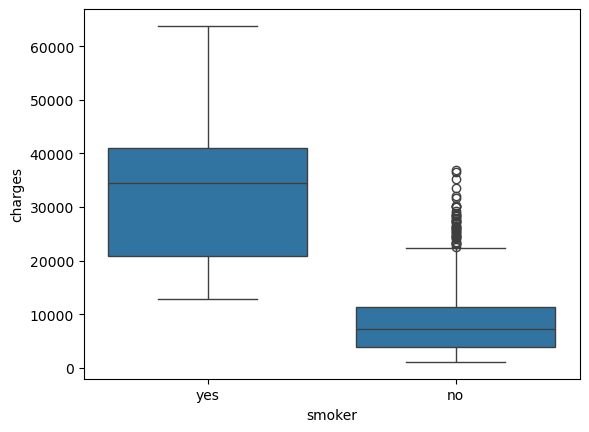

In [17]:
sns.boxplot(x = 'smoker', y ='charges', data =df)

### Inference

We clearly see that smokers have significantly higher expenses tha non-smokers.

Not only is the median higher, but the speard is also wide - indicating that
smoking is major cost driver in medical insurance.

This kind of visualization is critical for risk segmentation in the insurance industry.


In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcox,log_charges,bmi_cat,age_group,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult,0


<Axes: >

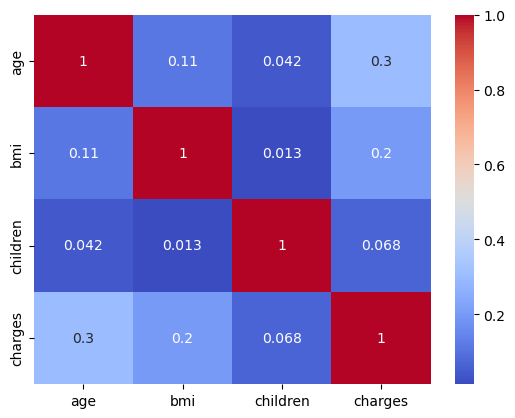

In [19]:
num_cols = ['age', 'bmi', 'children', 'charges']
corr =df[num_cols].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

## Check unique values for categorical fiels:



In [22]:
for col in ['sex','smoker','region','bmi_cat','age_group']:
    print(col, df[col].value_counts())
    print()

sex sex
male      676
female    662
Name: count, dtype: int64

smoker smoker
no     1064
yes     274
Name: count, dtype: int64

region region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

bmi_cat bmi_cat
obese     705
over      386
normal    226
under      21
Name: count, dtype: int64

age_group age_group
young     444
mature    409
adult     394
senior     91
Name: count, dtype: int64



## Target Variable Distribution

<Axes: xlabel='charges', ylabel='Count'>

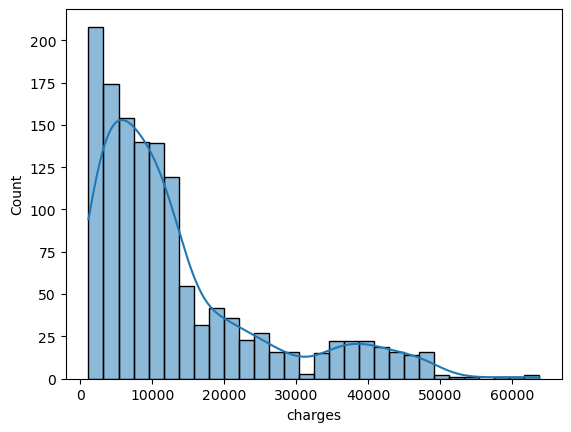

In [20]:
sns.histplot(df['charges'], kde = True)

In [21]:
## Compare original and transformed charges:

<Axes: xlabel='log_charges', ylabel='Count'>

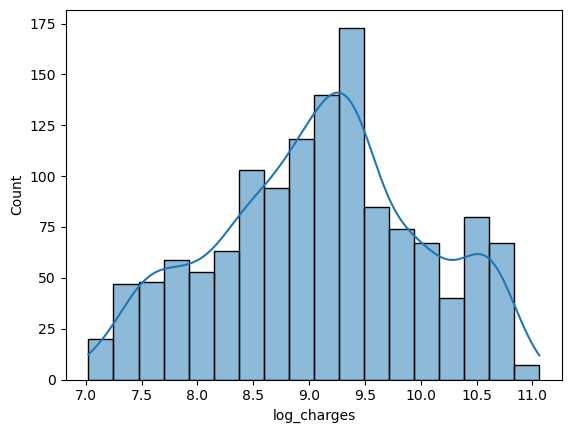

In [22]:
sns.histplot(df['log_charges'], kde = True)